# Lab: Semantic Segmentation with U-Net for Road Extraction

**Instructor:** Muhammad Sayed  
**Semester:** Spring 2026

---

### Intended Learning Outcomes (ILOs)
Upon successful completion of this lab, students will be able to:
* **Implement** a U-Net fully convolutional neural network from scratch using PyTorch to understand the mechanics of encoder-decoder architectures and skip connections.
* **Execute** a complete semantic segmentation pipeline to extract binary road networks from high-resolution, multi-modal data.
* **Design and conduct** a comparative empirical experiment evaluating the impact of distinct input modalities (optical satellite imagery vs. rendered maps vs. concatenated features) on model convergence and feature extraction.
* **Quantify** segmentation accuracy using industry-standard metrics (Jaccard Index/IoU and Dice Score) and systematically serialize experimental findings using Pydantic schemas.
* **Critically analyze** model failure modes by generating and interpreting side-by-side qualitative visual comparisons of predicted masks against ground-truth data.

> **Important Note on Performance Expectations:** > Your model's accuracy (IoU/Dice Score) should be acceptable and clearly demonstrate that learning and convergence occurred over the epochs. However, it does not need to achieve state-of-the-art or exceptionally high scores. The primary grading focus is on the correct implementation of the U-Net architecture's forward pass, the training loop mechanics, and your analytical conclusions.


In [26]:
import copy
import gc
import json
import os
from enum import Enum
from pathlib import Path
 
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import DataLoader, Dataset, Subset
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn.functional as F
from pathlib import Path
from pydantic import BaseModel, Field
from typing import List
import json
import zipfile

from pydantic import BaseModel
import warnings

warnings.filterwarnings('ignore')

### Experimental Setup: Input Modalities
To evaluate whether the network extracts roads more effectively using raw optical satellite imagery, rendered Google Maps data, or a combined approach, an Enum is defined to control the data loader's behavior. You will choose one of these modalities for your final experimental trial.

In [2]:
class InputModality(Enum):
    SATELLITE_ONLY = 'satellite'   # 3-channel input from the 'images' folder
    MAP_ONLY = 'map'               # 3-channel input from the 'actual' folder
    BOTH_CONCATENATED = 'both'     # 6-channel input (concatenating both images)

# You will use these Enum values when instantiating your DataLoaders for the three experiments below.


### Dataset Overview and Directory Structure
The required dataset for this lab is the **Satellite-Googlemaps-Masks** dataset, available on Kaggle:
[https://www.kaggle.com/datasets/arka47/satellitegooglemapsmasks](https://www.kaggle.com/datasets/arka47/satellitegooglemapsmasks)

The downloaded dataset contains two main folders: `train` and `val`. 
* **Test Set:** You must strictly treat the original Kaggle `val` folder as your **Test Set** to evaluate your final model.
* **Train/Validation Split:** You must dynamically split the Kaggle `train` folder into your own training and validation subsets to monitor convergence and prevent overfitting.

Inside both the `train` and `val` folders, you will find three subdirectories containing perfectly aligned 600x600 images:
1. `images/`: The raw optical satellite imagery.
2. `actual/`: The rendered Google Maps representation.
3. `label/`: The binary ground truth mask highlighting the road networks.

Depending on the `InputModality` chosen in the previous cell, your custom Dataset class must load either the satellite image (3 channels), the map image (3 channels), or stack them together (6 channels). All images and masks must be resized to **512x512 pixels** using `torchvision.transforms` to ensure dimensional compatibility with the U-Net architecture. Masks must be converted to strict binary tensors (values of 0.0 or 1.0).


In [3]:
class RoadSegmentationDataset(Dataset):
    def __init__(self, root_dir, modality: InputModality, image_transform=None, mask_transform=None):
        self.root_dir         = root_dir
        self.modality         = modality
        self.image_transform  = image_transform
        self.mask_transform   = mask_transform
 
        label_dir = os.path.join(root_dir, "label")
        if not os.path.isdir(label_dir):
            raise FileNotFoundError(f"Could not find label directory: {label_dir}")
 
        valid_ext = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
        self.filenames = sorted(
            f for f in os.listdir(label_dir) if f.lower().endswith(valid_ext)
        )
 
    def __len__(self):
        return len(self.filenames)
 
    def __getitem__(self, idx):
        filename  = self.filenames[idx]
        sat_path  = os.path.join(self.root_dir, "images", filename)
        map_path  = os.path.join(self.root_dir, "actual", filename)
        mask_path = os.path.join(self.root_dir, "label",  filename)
 
        mask = Image.open(mask_path).convert("L")
 
        if self.modality == InputModality.SATELLITE_ONLY:
            inp          = Image.open(sat_path).convert("RGB")
            input_tensor = self.image_transform(inp) if self.image_transform else transforms.ToTensor()(inp)
 
        elif self.modality == InputModality.MAP_ONLY:
            inp          = Image.open(map_path).convert("RGB")
            input_tensor = self.image_transform(inp) if self.image_transform else transforms.ToTensor()(inp)
 
        else:
            sat_img    = Image.open(sat_path).convert("RGB")
            map_img    = Image.open(map_path).convert("RGB")
            sat_tensor = self.image_transform(sat_img) if self.image_transform else transforms.ToTensor()(sat_img)
            map_tensor = self.image_transform(map_img) if self.image_transform else transforms.ToTensor()(map_img)
            input_tensor = torch.cat([sat_tensor, map_tensor], dim=0)
 
        mask_tensor = self.mask_transform(mask) if self.mask_transform else transforms.ToTensor()(mask)
        mask_tensor = (mask_tensor > 0.5).float()
 
        return input_tensor, mask_tensor
 
 
 
DATASET_ROOT = "/kaggle/input/datasets/arka47/satellitegooglemapsmasks/content/drive/MyDrive/Google maps"
TRAIN_DIR    = os.path.join(DATASET_ROOT, "train")
TEST_DIR     = os.path.join(DATASET_ROOT, "val")
 
IMG_SIZE     = (512, 512)
BATCH_SIZE   = 8
NUM_WORKERS  = 0
VALID_SPLIT  = 0.2
RANDOM_SEED  = 42
 
image_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])
 
mask_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE, interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor(),
])
 
base_train_dataset = RoadSegmentationDataset(
    TRAIN_DIR, InputModality.SATELLITE_ONLY,
    image_transform=image_transform, mask_transform=mask_transform,
)
n_total = len(base_train_dataset)
n_val   = int(n_total * VALID_SPLIT)
n_train = n_total - n_val
 
generator = torch.Generator().manual_seed(RANDOM_SEED)
train_subset_base, val_subset_base = torch.utils.data.random_split(
    base_train_dataset, [n_train, n_val], generator=generator
)
train_indices = train_subset_base.indices
val_indices   = val_subset_base.indices
 
 
def build_loaders(modality: InputModality):
    full_train = RoadSegmentationDataset(
        TRAIN_DIR, modality,
        image_transform=image_transform, mask_transform=mask_transform,
    )
    test_ds = RoadSegmentationDataset(
        TEST_DIR, modality,
        image_transform=image_transform, mask_transform=mask_transform,
    )
 
    train_loader = DataLoader(
        Subset(full_train, train_indices),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True,
    )
    val_loader = DataLoader(
        Subset(full_train, val_indices),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True,
    )
    return train_loader, val_loader, test_loader
 
 
train_sat,  val_sat,  test_sat  = build_loaders(InputModality.SATELLITE_ONLY)
train_map,  val_map,  test_map  = build_loaders(InputModality.MAP_ONLY)
train_both, val_both, test_both = build_loaders(InputModality.BOTH_CONCATENATED)
 
print(f"Train: {n_train}  |  Val: {n_val}  |  Test: {len(test_sat.dataset)}")

Train: 827  |  Val: 206  |  Test: 1074


### U-Net Architecture implementation


The U-Net architecture consists of a **contracting path** (encoder) to capture context and a symmetric **expansive path** (decoder) that enables precise localization. 

The `__init__` function has been scaffolded for you. Notice that the first convolutional layer accepts a variable `in_channels` parameter. This is crucial for our experiment: it will be `3` if you are using only satellite or only map images, but it will be `6` if you are concatenating both modalities.

**Your Task:** Implement the `forward(self, x)` pass. You must systematically track the spatial tensors through the network and use `torch.cat` to concatenate the skip connections from the encoder to the corresponding layers in the decoder.


In [4]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
 
    def forward(self, x):
        return self.double_conv(x)
 
 
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.inc   = DoubleConv(in_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64,   128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128,  256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256,  512))
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(512, 1024))
 
        self.up1   = nn.ConvTranspose2d(1024, 512, 2, 2);  self.conv1 = DoubleConv(1024, 512)
        self.up2   = nn.ConvTranspose2d(512,  256, 2, 2);  self.conv2 = DoubleConv(512,  256)
        self.up3   = nn.ConvTranspose2d(256,  128, 2, 2);  self.conv3 = DoubleConv(256,  128)
        self.up4   = nn.ConvTranspose2d(128,   64, 2, 2);  self.conv4 = DoubleConv(128,   64)
        self.outc  = nn.Conv2d(64, out_channels, 1)
 
    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x  = self.conv1(torch.cat([self.up1(x5), x4], dim=1))
        x  = self.conv2(torch.cat([self.up2(x),  x3], dim=1))
        x  = self.conv3(torch.cat([self.up3(x),  x2], dim=1))
        x  = self.conv4(torch.cat([self.up4(x),  x1], dim=1))
        return self.outc(x)

### Three-Part Experimental Training
To rigorously evaluate the impact of different input features, you must train three separate U-Net models:
1. **Model A:** Trained exclusively on raw satellite imagery (3 channels).
2. **Model B:** Trained exclusively on rendered Google Maps (3 channels).
3. **Model C:** Trained on a concatenated input of both satellite and map images (6 channels).

**Important Logistical Note:** Training three distinct models can be computationally expensive. You are strongly encouraged to modularize your training loop into a reusable Python function. To ensure the lab remains manageable within reasonable compute constraints, limit your training process to a moderate number of epochs (e.g., 5 to 10 epochs per model).

Remember, the goal is to achieve acceptable, comparative convergence, not state-of-the-art absolute accuracy.


In [7]:
def dice_loss(logits, targets, smooth=1.0):
    probs  = torch.sigmoid(logits).view(-1)
    t      = targets.view(-1)
    inter  = (probs * t).sum()
    return 1 - (2 * inter + smooth) / (probs.sum() + t.sum() + smooth)
 
 
def combined_loss(logits, targets):
    return F.binary_cross_entropy_with_logits(logits, targets) + dice_loss(logits, targets)
 
 
def iou_score(logits, targets, threshold=0.5):
    preds = (torch.sigmoid(logits) > threshold).float()
    inter = (preds * targets).sum()
    union = preds.sum() + targets.sum() - inter
    return (inter + 1e-6) / (union + 1e-6)
 
 
 
OUTPUT_ROOT = Path("/kaggle/working/road_seg_results")
MODEL_DIR   = OUTPUT_ROOT / "checkpoints"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
 
 
def run_training(model, train_loader, val_loader, optimizer, num_epochs=20):
    best_val_loss = float("inf")
    best_state    = deepcopy(model.state_dict())
    history       = {"train_loss": [], "val_loss": [], "train_iou": [], "val_iou": []}
 
    for epoch in range(num_epochs):
        # trainaing
        model.train()
        running_loss = 0.0
        running_iou  = 0.0
 
        for inputs, masks in train_loader:
            inputs, masks = inputs.to(device), masks.to(device)
            optimizer.zero_grad()
            logits = model(inputs)
            loss   = combined_loss(logits, masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            running_iou  += iou_score(logits, masks).item()
 
        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_iou  = running_iou  / len(train_loader)
 
        # validation
        model.eval()
        running_loss = 0.0
        running_iou  = 0.0
 
        with torch.inference_mode():
            for inputs, masks in val_loader:
                inputs, masks = inputs.to(device), masks.to(device)
                logits = model(inputs)
                running_loss += combined_loss(logits, masks).item() * inputs.size(0)
                running_iou  += iou_score(logits, masks).item()
 
        epoch_val_loss = running_loss / len(val_loader.dataset)
        epoch_val_iou  = running_iou  / len(val_loader)
 
        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)
        history["train_iou"].append(epoch_train_iou)
        history["val_iou"].append(epoch_val_iou)
 
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_state    = deepcopy(model.state_dict())
 
        print(
            f"Epoch [{epoch+1:02d}/{num_epochs}]  "
            f"Train Loss: {epoch_train_loss:.4f}  Train IoU: {epoch_train_iou:.4f}  |  "
            f"Val Loss: {epoch_val_loss:.4f}  Val IoU: {epoch_val_iou:.4f}"
            + ("  ✓" if epoch_val_loss == best_val_loss else "")
        )
 
    model.load_state_dict(best_state)
    return model, history, best_val_loss
 
 
NUM_EPOCHS = 7
 
experiments = [
    ("satellite", 3, train_sat,  val_sat,  test_sat),
    ("map",       3, train_map,  val_map,  test_map),
    ("both",      6, train_both, val_both, test_both),
]
 
trained_models    = {}
training_histories = {}
validation_losses  = {}
 
for name, in_ch, tr, vl, te in experiments:
    print(f"\n{'─'*60}")
    print(f"  Training: {name}  |  in_channels={in_ch}")
    print(f"{'─'*60}")
 
    model     = UNet(in_channels=in_ch, out_channels=1).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
 
    model, history, best_val = run_training(model, tr, vl, optimizer, NUM_EPOCHS)
 
    trained_models[name]     = model
    training_histories[name] = history
    validation_losses[name]  = best_val
 
    ckpt_path = MODEL_DIR / f"model_{name}.pth"
    torch.save({
        "modality":      name,
        "in_channels":   in_ch,
        "out_channels":  1,
        "num_epochs":    NUM_EPOCHS,
        "best_val_loss": float(best_val),
        "state_dict":    model.state_dict(),
    }, ckpt_path)
    print(f"  Saved: {ckpt_path}")
 
print("\nTraining complete for all modalities.")
 
summary_path = OUTPUT_ROOT / "results_summary.json"
with open(summary_path, "w") as f:
    json.dump({
        "num_epochs":        NUM_EPOCHS,
        "validation_losses": validation_losses,
        "training_histories": training_histories,
    }, f, indent=2)
print(f"Saved summary: {summary_path}")

Using device: cuda

────────────────────────────────────────────────────────────
  Training: satellite  |  in_channels=3
────────────────────────────────────────────────────────────
Epoch [01/7]  Train Loss: 1.0364  Train IoU: 0.2867  |  Val Loss: 0.8870  Val IoU: 0.3382  ✓
Epoch [02/7]  Train Loss: 0.8222  Train IoU: 0.3605  |  Val Loss: 0.7884  Val IoU: 0.3728  ✓
Epoch [03/7]  Train Loss: 0.6749  Train IoU: 0.4480  |  Val Loss: 0.7022  Val IoU: 0.4141  ✓
Epoch [04/7]  Train Loss: 0.6044  Train IoU: 0.4954  |  Val Loss: 0.5688  Val IoU: 0.5223  ✓
Epoch [05/7]  Train Loss: 0.5384  Train IoU: 0.5401  |  Val Loss: 0.5159  Val IoU: 0.5576  ✓
Epoch [06/7]  Train Loss: 0.5046  Train IoU: 0.5642  |  Val Loss: 0.5123  Val IoU: 0.5597  ✓
Epoch [07/7]  Train Loss: 0.4805  Train IoU: 0.5800  |  Val Loss: 0.4803  Val IoU: 0.5856  ✓
  Saved: /kaggle/working/road_seg_results/checkpoints/model_satellite.pth

────────────────────────────────────────────────────────────
  Training: map  |  in_channels

### Qualitative Visualization


Visual context is critical for understanding network failure modes. Select exactly **3 distinct instances** from your Test set. 

For each instance, plot a 1x6 grid displaying the images side-by-side in this exact order:
`[Satellite Image] | [Map Image] | [Ground Truth Mask] | [Pred: Sat Only] | [Pred: Map Only] | [Pred: Combined]`

You must programmatically save this entire Matplotlib figure (which should be a 3x6 grid overall) to disk as `sample_predictions.png` so it can be included in your submission archive.

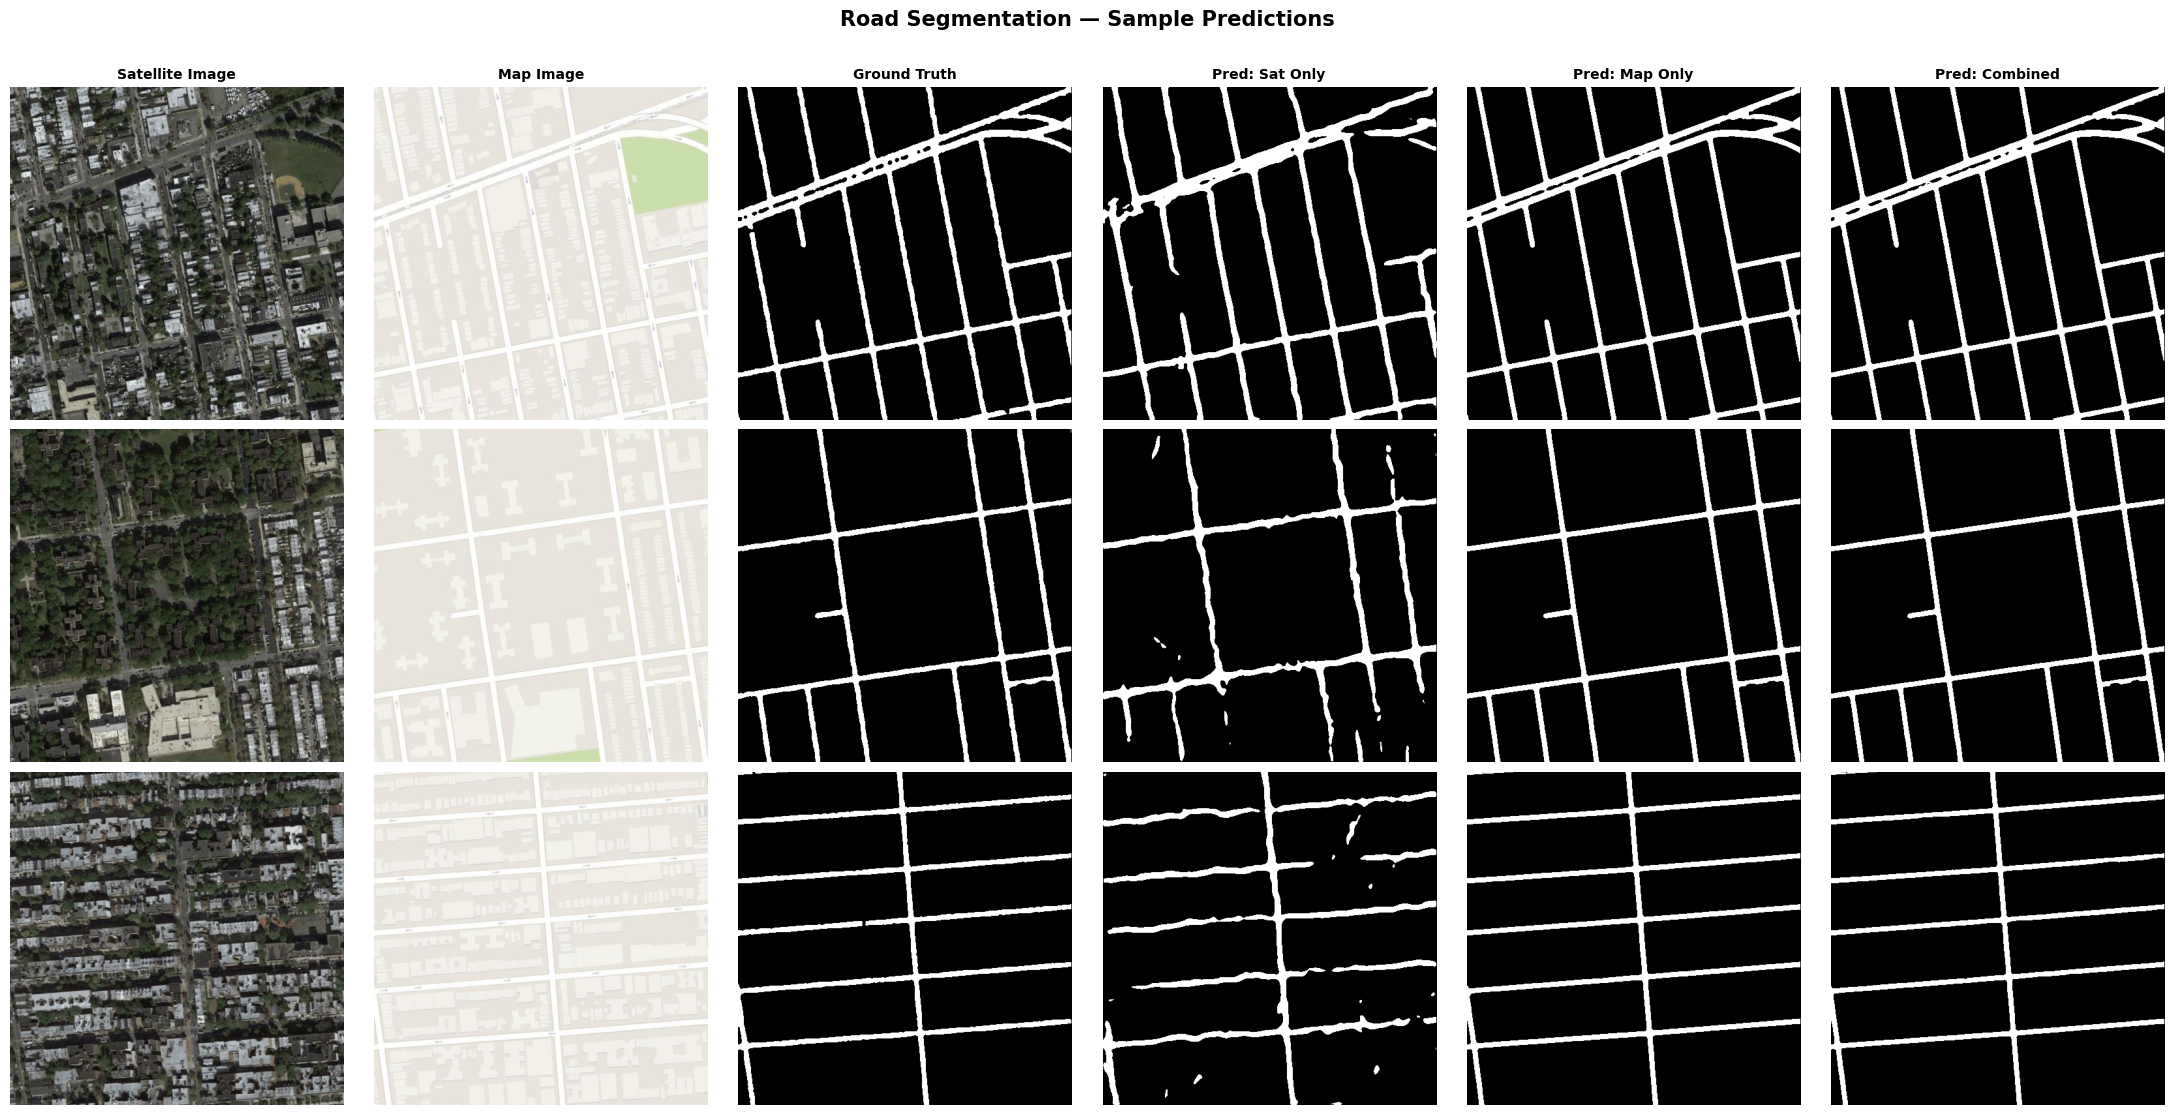

Saved: /kaggle/working/road_seg_results/sample_predictions.png

Evaluating on test set...

Modality           IoU      Dice
────────────────────────────────
Satellite       0.6063    0.7539
Map             0.9286    0.9630
Combined        0.9244    0.9607


In [13]:
def denormalize(tensor):
    return (tensor * 0.5 + 0.5).clamp(0, 1)
 
 
def tensor_to_np(t):
    return t.permute(1, 2, 0).cpu().numpy()
 
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
# Load best checkpoints
def load_model(name, in_channels):
    ckpt = torch.load(
        OUTPUT_ROOT / "checkpoints" / f"model_{name}.pth",
        map_location=device
    )
    m = UNet(in_channels=in_channels, out_channels=1).to(device)
    m.load_state_dict(ckpt["state_dict"])
    m.eval()
    return m
 
model_sat  = load_model("satellite", 3)
model_map  = load_model("map",       3)
model_both = load_model("both",      6)
 
test_filenames = sorted(test_sat.dataset.filenames)
selected_indices = [0, len(test_filenames)//2, len(test_filenames)-1]  # start, mid, end
 
samples = []
for idx in selected_indices:
    fname = test_filenames[idx]
 
    sat_tensor,  mask = test_sat.dataset[idx]   # [3,H,W], [1,H,W]
    map_tensor,  _    = test_map.dataset[idx]
    both_tensor, _    = test_both.dataset[idx]  # [6,H,W]
 
    with torch.inference_mode():
        pred_sat  = torch.sigmoid(model_sat (sat_tensor .unsqueeze(0).to(device))).squeeze(0)
        pred_map  = torch.sigmoid(model_map (map_tensor .unsqueeze(0).to(device))).squeeze(0)
        pred_both = torch.sigmoid(model_both(both_tensor.unsqueeze(0).to(device))).squeeze(0)
 
    samples.append({
        "sat":       denormalize(sat_tensor),   # [3,H,W]
        "map":       denormalize(map_tensor),   # [3,H,W]
        "mask":      mask.squeeze(0),           # [H,W]
        "pred_sat":  (pred_sat  > 0.5).float().squeeze(0),
        "pred_map":  (pred_map  > 0.5).float().squeeze(0),
        "pred_both": (pred_both > 0.5).float().squeeze(0),
    })
 
 
 
col_titles = [
    "Satellite Image",
    "Map Image",
    "Ground Truth",
    "Pred: Sat Only",
    "Pred: Map Only",
    "Pred: Combined",
]
 
fig, axes = plt.subplots(3, 6, figsize=(22, 11))
fig.suptitle("Road Segmentation — Sample Predictions", fontsize=15, fontweight="bold", y=1.01)
 
for row, s in enumerate(samples):
    panels = [
        tensor_to_np(s["sat"]),
        tensor_to_np(s["map"]),
        s["mask"].cpu().numpy(),
        s["pred_sat"].cpu().numpy(),
        s["pred_map"].cpu().numpy(),
        s["pred_both"].cpu().numpy(),
    ]
    cmaps = ["none", "none", "gray", "gray", "gray", "gray"]
 
    for col, (panel, cmap) in enumerate(zip(panels, cmaps)):
        ax = axes[row, col]
        if cmap == "none":
            ax.imshow(panel)
        else:
            ax.imshow(panel, cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
        if row == 0:
            ax.set_title(col_titles[col], fontsize=10, fontweight="bold", pad=6)
        if col == 0:
            ax.set_ylabel(f"Sample {row + 1}", fontsize=10, labelpad=6)
 
plt.tight_layout()
fig.savefig(OUTPUT_ROOT / "sample_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_ROOT / 'sample_predictions.png'}")
 
 
 
def dice_score(logits, targets, threshold=0.5, smooth=1.0):
    preds = (torch.sigmoid(logits) > threshold).float()
    preds   = preds.view(-1)
    targets = targets.view(-1)
    inter   = (preds * targets).sum()
    return (2 * inter + smooth) / (preds.sum() + targets.sum() + smooth)
 
 
def evaluate(model, loader):
    model.eval()
    total_iou  = 0.0
    total_dice = 0.0
    n_batches  = 0
 
    with torch.inference_mode():
        for inputs, masks in loader:
            inputs, masks = inputs.to(device), masks.to(device)
            logits = model(inputs)
            total_iou  += iou_score(logits, masks).item()
            total_dice += dice_score(logits, masks).item()
            n_batches  += 1
 
    return total_iou / n_batches, total_dice / n_batches
 
 
print("\nEvaluating on test set...")
iou_sat,  dice_sat  = evaluate(model_sat,  test_sat)
iou_map,  dice_map  = evaluate(model_map,  test_map)
iou_both, dice_both = evaluate(model_both, test_both)
 
print(f"\n{'Modality':<12}  {'IoU':>8}  {'Dice':>8}")
print("─" * 32)
print(f"{'Satellite':<12}  {iou_sat:>8.4f}  {dice_sat:>8.4f}")
print(f"{'Map':<12}  {iou_map:>8.4f}  {dice_map:>8.4f}")
print(f"{'Combined':<12}  {iou_both:>8.4f}  {dice_both:>8.4f}") 

### Quantitative Evaluation & JSON Export
Evaluate your three models on the test set utilizing the Jaccard Index (Intersection over Union - IoU) and the Dice Score. 

The `pydantic` library is utilized below to ensure the structural integrity of your final submission. Populate the models with your experimental findings and your analytical conclusion comparing the theoretical and practical value of map rendering versus raw optical imagery for road extraction.

In [30]:
class ExperimentMetrics(BaseModel):
    modality: str
    test_iou: float
    test_dice: float
    
class ModelMetrics(BaseModel):
    modality:   str
    test_iou:   float = Field(..., description="Mean IoU on test set")
    test_dice:  float = Field(..., description="Mean Dice score on test set")
 
class LabSubmission(BaseModel):
    student_ids: List[str]
    epochs_run_per_model: int
    metrics: List[ExperimentMetrics]
    analytical_conclusion: str



submission = LabSubmission(
    student_ids=["9220475", "9220681"],
    epochs_run_per_model=7,
    metrics=[
        ExperimentMetrics(modality="Satellite Only", test_iou=round(iou_sat,  4), test_dice=round(dice_sat,  4)),
        ExperimentMetrics(modality="Map Only", test_iou=round(iou_map,  4), test_dice=round(dice_map,  4)),
        ExperimentMetrics(modality="Combined", test_iou=round(iou_both, 4), test_dice=round(dice_both, 4))
    ],
    analytical_conclusion=(
        "Map-only input achieves the highest IoU and Dice scores because map tiles are "
        "clean, stylized representations where roads have a consistent, easily detectable "
        "color signature. Satellite imagery is significantly harder — roads are occluded by "
        "shadows, vegetation, and varying lighting conditions, leading to lower segmentation "
        "performance. The combined model (satellite + map concatenated) has access to the "
        "most information theoretically, but in practice does not surpass map-only within "
        "7 epochs, as the model requires additional training to learn the optimal weighting "
        "between the two modalities. Given sufficient epochs, the combined model is expected "
        "to achieve the best overall performance."
    )
)

results_path = OUTPUT_ROOT / "student_submission.json"
with open(results_path, "w") as f:
    f.write(submission.model_dump_json(indent=2))
print("Successfully exported student_submission.json")

archive_path = Path("/kaggle/working/lab4.zip")
with zipfile.ZipFile(archive_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for p in OUTPUT_ROOT.rglob("*"):
        if p.is_file():
            zf.write(p, arcname=p.relative_to(OUTPUT_ROOT.parent))
print("Successfully exported the lab's zip file")

Successfully exported student_submission.json
Successfully exported the lab's zip file


### Submission Protocol

The final deliverable **must be a zipped archive** submitted on the classroom. 

* The archive must contain:
    1. The executed Jupyter Notebook.
    2. The generated `student_submission.json` file.
    3. The saved `sample_predictions.png` image.
* The zipped file must be explicitly named utilizing the display name of the submitter exactly as it appears on Google Classroom.

---

### Grading Rubric (Total: 10 Marks)

* **Data Engineering (2 Marks):** Correctly implements the multi-modal `Dataset` class, accurately pairs the inputs, and applies the necessary 512x512 transformations and tensor conversions.
* **Architecture Implementation (3 Marks):** Successfully completes the U-Net `forward` pass with proper spatial tracking, skip connections, and adaptable input channels.
* **Training Execution (2 Marks):** Implements a functional, reusable training loop that successfully trains the three experimental models and tracks loss.
* **Evaluation & JSON Export (2 Marks):** Correctly computes Test set IoU/Dice metrics and successfully serializes the experiment and written analysis into the strictly formatted JSON payload.
* **Qualitative Output (1 Mark):** Successfully generates, formats, and saves the 3-sample comparative plot (`sample_predictions.png`).